# NemoIR Covertype XGBoost Autoresearch — Viewer Notebook

**Pre-rendered on GitHub:** the trace and 5 dashboard figures below were captured from a live 32-trial run (CUDA, `eps=0.002`). No dataset download, GPU, or API key needed to *view*.

- **Workflow:** `autoresearch.nemo` — declarative `candidate.json` sole writable, frozen `harness/*`, compiled numeric guard `score - best > eps` on stratified `selection`/`confirmation` splits, hidden `final` split.
- **Local run:** `git clone https://github.com/hkalexling/nemoir && cd public/demos/xgboost-autoresearch && python -m venv .venv && .venv/bin/pip install -r requirements.txt && .venv/bin/python harness/data.py prepare && cp .env.example .env` then `.venv/bin/python run.py --device cpu --max-trials 10`
- **Colab path:** cells 1–4 fetch a Drive zip — **skip on local checkout** (you already have the code).
- **Viewer note:** last cell `plot_run(run_dir)` only reads `runs/*` evidence (no model call) — figures are pre-rendered.

> Badge: [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hkalexling/nemoir/blob/main/public/demos/xgboost-autoresearch/demo.ipynb)


<a href="https://colab.research.google.com/github/hkalexling/nemoir/blob/main/public/demos/xgboost-autoresearch/demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Above badge now points to the public demo. The private gist is retained for history but not needed on a local checkout.*

In [1]:
# Colab bootstrap — skip on local checkout (you already have public/demos/xgboost-autoresearch/)
!gdown 1td7PwIId64G4i0xJZsF7ZRrjjlNlq_Qb

Downloading...
From: https://drive.google.com/uc?id=1td7PwIId64G4i0xJZsF7ZRrjjlNlq_Qb
To: /content/xgboost-autoresearch-colab.zip
100% 66.1k/66.1k [00:00<00:00, 74.4MB/s]


In [2]:
# Colab: unzip fetched archive — skip locally
!unzip xgboost-autoresearch-colab.zip

Archive:  xgboost-autoresearch-colab.zip
   creating: xgboost-autoresearch/
  inflating: xgboost-autoresearch/requirements.txt  
   creating: xgboost-autoresearch/harness/
  inflating: xgboost-autoresearch/harness/preflight.py  
  inflating: xgboost-autoresearch/harness/train.py  
  inflating: xgboost-autoresearch/harness/final_eval.py  
  inflating: xgboost-autoresearch/harness/evaluate.py  
  inflating: xgboost-autoresearch/harness/metrics.py  
  inflating: xgboost-autoresearch/harness/__init__.py  
  inflating: xgboost-autoresearch/harness/experiment.py  
  inflating: xgboost-autoresearch/harness/baseline.py  
  inflating: xgboost-autoresearch/harness/data.py  
  inflating: xgboost-autoresearch/harness/config.py  
  inflating: xgboost-autoresearch/harness/artifacts.py  
  inflating: xgboost-autoresearch/harness/features.py  
  inflating: xgboost-autoresearch/harness/state.py  
   creating: xgboost-autoresearch/requirements/
  inflating: xgboost-autoresearch/requirements/plots.txt  


In [3]:
# Colab: %cd into fetched dir — skip locally (already in demo dir)
%cd xgboost-autoresearch/

/content/xgboost-autoresearch


In [4]:
# Colab deps — locally: pip install -r requirements.txt (see README)
!pip install -r requirements.txt -e .

Obtaining file:///content/xgboost-autoresearch
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.1/278.1 kB 27.4 MB/s eta 0:00:00
  Building editable for covertype-xgb-autoresearch (pyproject.toml) ... done
  Created wheel for covertype-xgb-autoresearch: filename=covertype_xgb_autoresearch-0.1.0-0.editable-py3-none-any.whl size=2965 sha256=fda224171c147fe722859fef1761679e0298cedaa377ce56faf7de29f5a88fbe
  Stored in directory: /tmp/pip-ephem-wheel-cache-vfiw2d3q/wheels/1b/4d/c3/7199f9cd9a7fa0d295436ccab4cc73c0cf03182dcb62d6813e
Successfully built covertype-xgb-autoresearch
  Attempting uninstall: importlib-metadata
    Found exi

In [5]:
# Prepare fingerprint — locally: python harness/data.py prepare (same log below)
!python harness/data.py prepare

{"dataset_fingerprint": "3544b9be686308407f64a6bf950c6d883e21df787da57fa5aae131f0561dc3b1", "dataset_manifest": "/content/xgboost-autoresearch/data/dataset_manifest.json", "ok": true, "shape": [581012, 54], "split_indices_sha256": "bb40cc14a7ea7012168a346364460d33ebea76037fac422926c18e15fa55fd5b", "split_manifest": "/content/xgboost-autoresearch/data/split_manifest.json", "split_sizes": {"confirmation": 29050, "early_stop": 58101, "final": 58102, "fit": 348607, "selection": 87152}}


In [6]:
# Run — Colab uses userdata.get(); locally .env / env var works too (see README). Use --device cpu on non-CUDA hosts.
from google.colab import userdata
import os

os.environ["NEMOIR_API_KEY"] = os.environ.get("NEMOIR_API_KEY") or userdata.get("DEEPSEEK_API_KEY")
# Tip: locally, set NEMOIR_API_KEY in .env instead of userdata
os.environ["NEMOIR_MODEL"] = "deepseek/deepseek-v4-pro"
assert os.environ["NEMOIR_API_KEY"]

!python run.py --device cuda --max-trials 32 --max-steps 9999  # locally CPU: --device cpu --max-trials 10

Covertype XGBoost autoresearch: run=20260719T124116Z-fa386833 device=cuda trials=32 eps=0.002

-- Init --
  [os.shell] run_harness
  output: trial_count=0
  -> Baseline

-- Baseline --
  [os.shell] run_harness
  output: score=0.559283, selection_score=0.557004, confirmation_score=0.561562
  -> AdoptBaseline

-- AdoptBaseline --
  [os.shell] run_harness
  output: score=0.559283, best_score=0.559283, selection_score=0.557004, confirmation_score=0.561562, trial_count=0
  -> StartTrial

-- StartTrial --
  [os.shell] run_harness
  output: best_score=0.559283, trial_count=1
  -> AnalyzeHistory

-- AnalyzeHistory --
  [fs.read] read_agent_file
{
  "analysis": "The baseline candidate uses minimal_v1 (10 continuous features only), which drops the 44 binary wilderness/soil one-hot columns. The Covertype dataset is known to have strong predictive signals in soil type, so moving to raw_v1 (all 54 features) is likely to improve macro-F1. Additionally, the baseline uses only 50 trees with a high lea

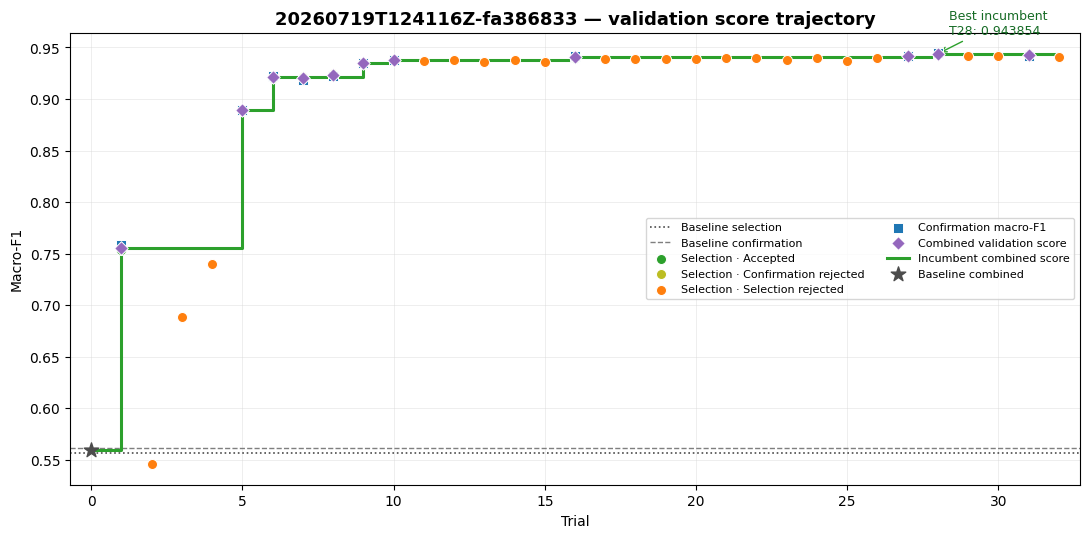

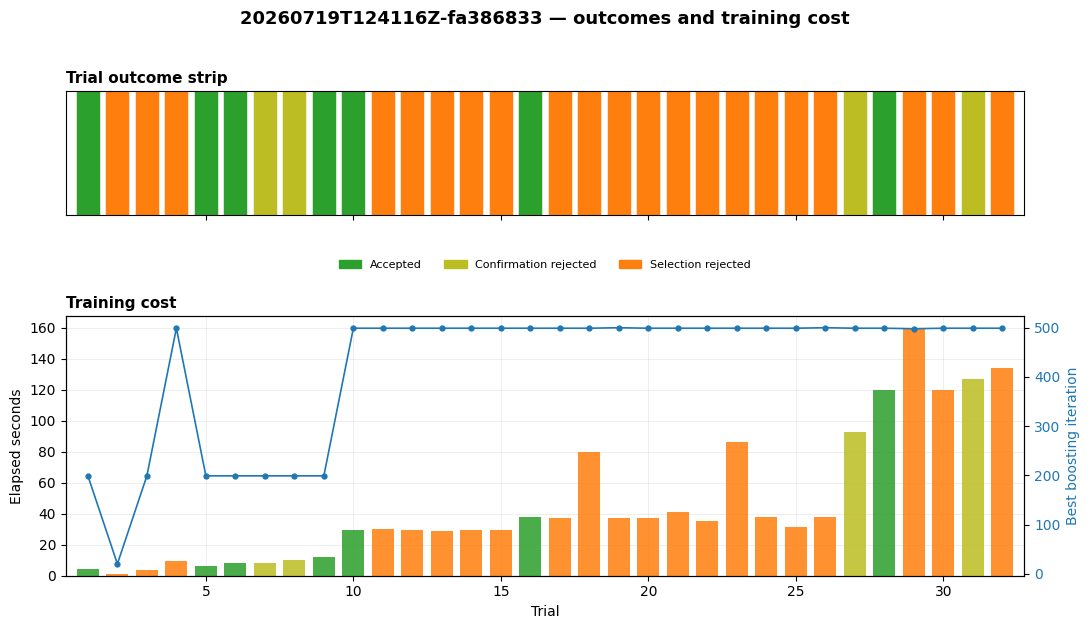

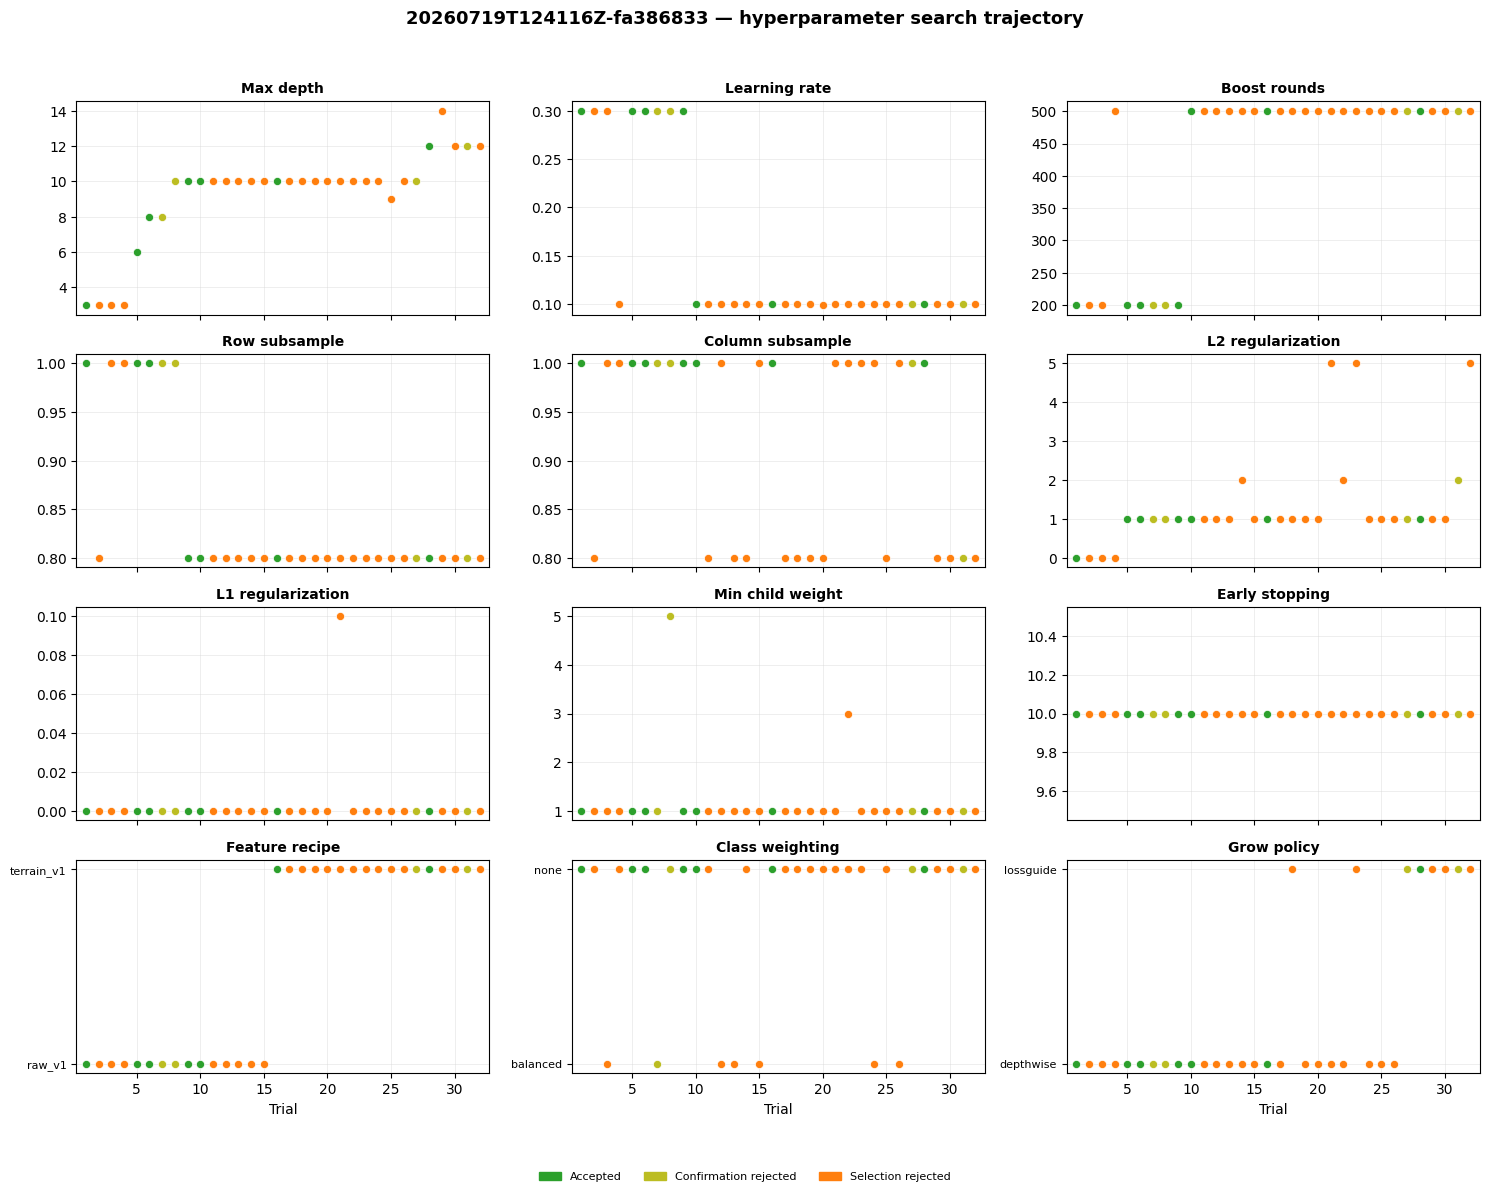

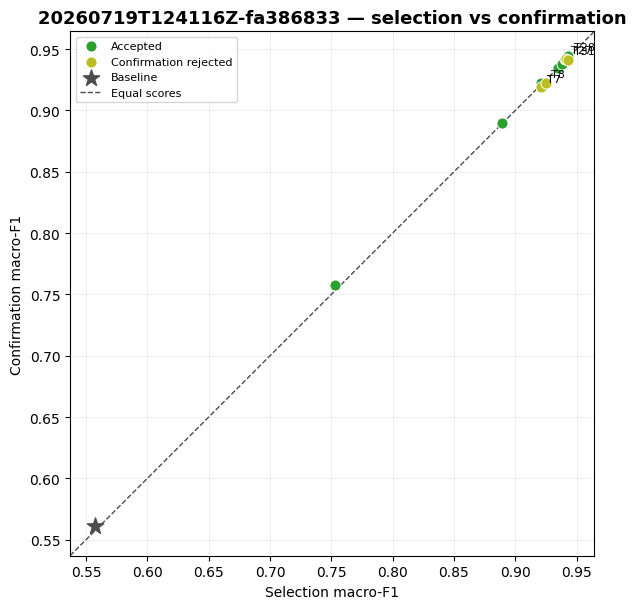

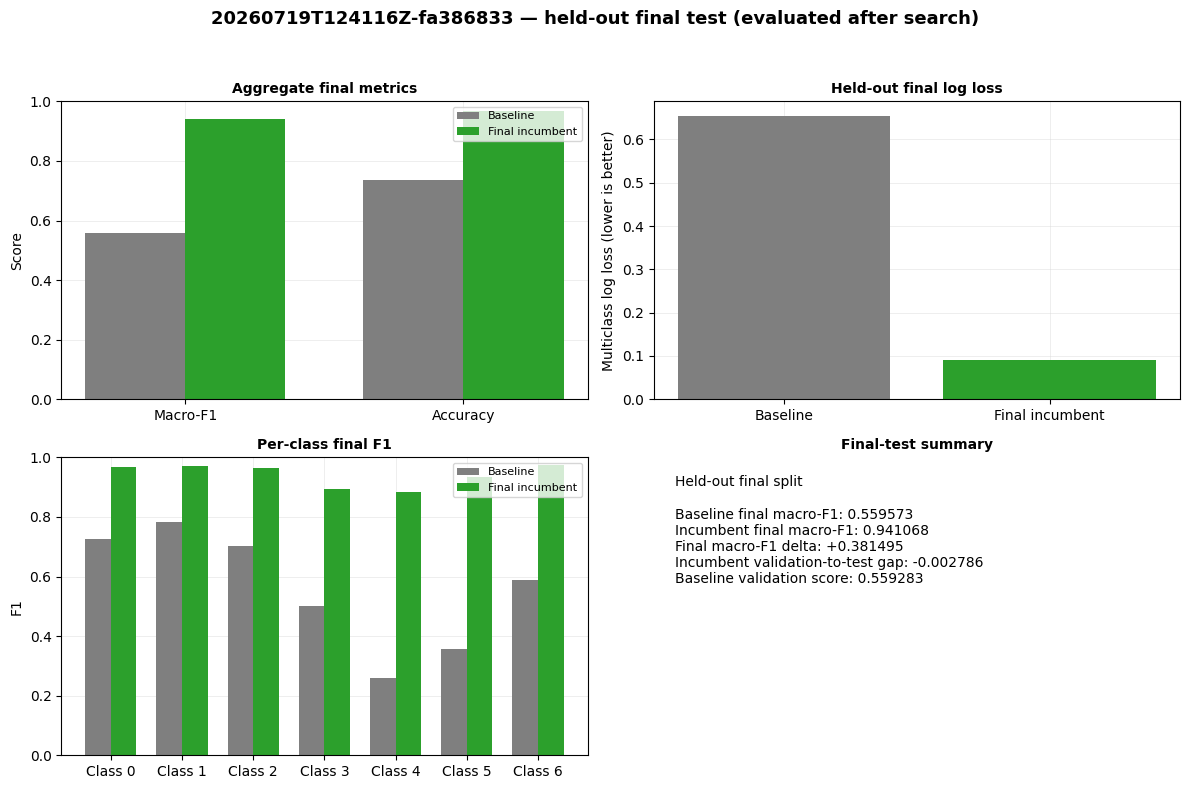

{'run_id': '20260719T124116Z-fa386833',
 'run_dir': '/content/xgboost-autoresearch/runs/20260719T124116Z-fa386833',
 'trial_count': 32,
 'evaluated_trials': 32,
 'accepted_trials': 7,
 'outcome_counts': {'accepted': 7,
  'confirmation_rejected': 4,
  'primary_rejected': 21},
 'baseline': {'selection_score': 0.557004,
  'confirmation_score': 0.561562,
  'combined_score': 0.559283},
 'best_incumbent': {'trial': 28, 'combined_score': 0.943854},
 'total_training_seconds': 1493.349499,
 'final_test': {'available': True,
  'macro_f1': 0.941068,
  'accuracy': 0.966283,
  'validation_combined_score': 0.943854}}

In [7]:
# Viewer — last cell only reads runs/* evidence (no model call). Figures below are pre-rendered.
!pip -q install -r requirements/plots.txt

from pathlib import Path
from plot_run import plot_run

run_dirs = [
       path for path in Path("runs").iterdir()
       if path.is_dir() and (path / "run_manifest.json").exists()
]
run_dir = max(run_dirs, key=lambda path: path.stat().st_mtime)

dashboard = plot_run(run_dir)
dashboard.summary

**Above:** 5 inline figures + `dashboard.summary` from the live run. Run `plot_run(run_dir, show=False)` locally to regenerate from `runs/*` without calling the model.